## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Style
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})
COLORS = {"Low":"#E74C3C", "Moderate":"#F39C12", "High":"#2ECC71"}

df = pd.read_csv("/content/gdrive/MyDrive/STAT3013/Dataset/data_cleaned.csv")
df["volume_category"] = pd.Categorical(df["volume_category"],
    categories=["Low","Moderate","High"], ordered=True)
df["hyp_class"] = pd.Categorical(df["hyp_class"],
    categories=["Low","Medium","High"], ordered=True)

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df[["hedges_g","sets.week.all","frequency.direct","weeks","age"]].describe().round(3)

Loaded: 198 rows, 36 columns


,hedges_g,sets.week.all,frequency.direct,weeks,age
count,198.000,198.000,198.000,198.000,198.000
mean,0.429,15.504,2.112,9.990,26.064
std,0.370,10.894,1.190,3.613,5.847
min,-0.208,0.000,0.000,6.000,19.500
25%,0.145,6.947,1.000,8.000,22.500
50%,0.360,12.000,2.000,8.500,23.800
75%,0.615,24.000,3.000,11.750,26.700
max,2.259,48.000,6.000,24.330,45.400


## 1. Bảng thống kê mô tả đầy đủ

In [5]:
# Các biến chính cần báo cáo
KEY_VARS = {
    "hedges_g":                "Hedges g (TARGET)",
    "sets.week.all":           "Sets/Week (all)",
    "sets.week.direct":        "Sets/Week (direct)",
    "frequency.direct":        "Frequency (direct)",
    "sessions.per.week":       "Sessions/Week",
    "reps.week.all":           "Reps/Week",
    "rep.range.all":           "Rep Range",
    "interset.rest.min.all":   "Rest (min)",
    "percentage.failure.all":  "% Failure",
    "weeks":                   "Duration (weeks)",
    "age":                     "Age",
    "sex.male":                "% Male",
    "body.mass":               "Body Mass (kg)",
    "years.exp":               "Years Experience",
}

rows = []
for col, label in KEY_VARS.items():
    s = df[col].dropna()
    rows.append({
        "Variable":   label,
        "N":          len(s),
        "Mean":       round(s.mean(), 3),
        "Median":     round(s.median(), 3),
        "SD":         round(s.std(), 3),
        "Min":        round(s.min(), 3),
        "Max":        round(s.max(), 3),
        "Q1":         round(s.quantile(0.25), 3),
        "Q3":         round(s.quantile(0.75), 3),
    })

desc_table = pd.DataFrame(rows)
desc_table.to_csv("/content/gdrive/MyDrive/STAT3013/Dataset/descriptive_stats.csv", index=False)
print("Saved: descriptive_stats.csv")
desc_table

Saved: descriptive_stats.csv


,Variable,N,Mean,Median,SD,Min,Max,Q1,Q3
0,Hedges g (TARGET),198,0.429,0.360,0.370,-0.208,2.259,0.145,0.615
1,Sets/Week (all),198,15.504,12.000,10.894,0.000,48.000,6.947,24.000
2,Sets/Week (direct),198,10.585,9.000,8.903,0.000,45.000,4.742,14.750
3,Frequency (direct),198,2.112,2.000,1.190,0.000,6.000,1.000,3.000
4,Sessions/Week,198,3.031,3.000,1.441,0.000,8.000,2.000,4.000
5,Reps/Week,198,151.250,135.135,107.730,0.000,480.000,60.000,216.000
6,Rep Range,198,10.503,10.000,1.847,7.000,21.660,9.600,11.100
7,Rest (min),198,1.837,2.000,0.657,1.000,4.111,1.500,2.000
8,% Failure,198,83.584,100.000,34.436,0.000,100.000,100.000,100.000
9,Duration (weeks),198,9.990,8.500,3.613,6.000,24.330,8.000,11.750


## 2. Phân phối theo train.status và volume_category

In [6]:
print("=== Train Status ===")
print(df["train.status"].value_counts())
print()
print("=== Volume Category ===")
print(df["volume_category"].value_counts().sort_index())
print()
print("=== Hyp Class ===")
print(df["hyp_class"].value_counts().sort_index())
print()
print("=== Nutrition ===")
print(df["nutrition_category"].value_counts())

=== Train Status ===
train.status
trained      117
untrained     81
Name: count, dtype: int64

=== Volume Category ===
volume_category
Low         48
Moderate    61
High        89
Name: count, dtype: int64

=== Hyp Class ===
hyp_class
Low        60
Medium    112
High       26
Name: count, dtype: int64

=== Nutrition ===
nutrition_category
Surplus    6
Deficit    4
Name: count, dtype: int64


## 3. Figure 1 — Histogram phân phối Hedges g

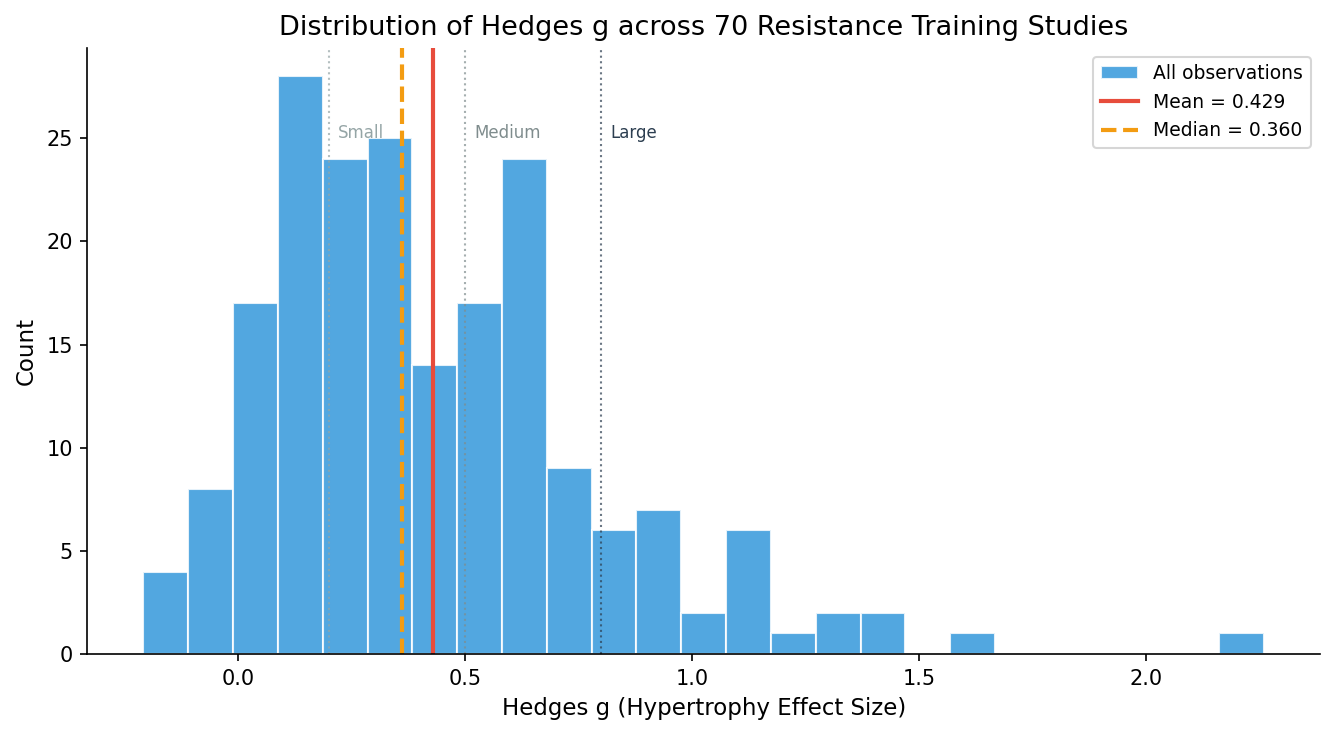

Saved: fig1_hedges_g_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(9,5))

ax.hist(df["hedges_g"], bins=25, color="#3498DB", edgecolor="white",
        alpha=0.85, label="All observations")

# Mean & Median lines
ax.axvline(df["hedges_g"].mean(),   color="#E74C3C", lw=2, ls="-",  label=f"Mean = {df['hedges_g'].mean():.3f}")
ax.axvline(df["hedges_g"].median(), color="#F39C12", lw=2, ls="--", label=f"Median = {df['hedges_g'].median():.3f}")

# Effect size benchmarks
for g_val, lbl, c in [(0.2,"Small","#95A5A6"), (0.5,"Medium","#7F8C8D"), (0.8,"Large","#2C3E50")]:
    ax.axvline(g_val, color=c, lw=1, ls=":", alpha=0.7)
    ax.text(g_val+0.02, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1]>0 else 10,
            lbl, fontsize=8, color=c)

ax.set_xlabel("Hedges g (Hypertrophy Effect Size)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Hedges g across 70 Resistance Training Studies")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig1_hedges_g_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig1_hedges_g_distribution.png")

## 4. Figure 2 — Boxplot Hedges g theo Volume Category

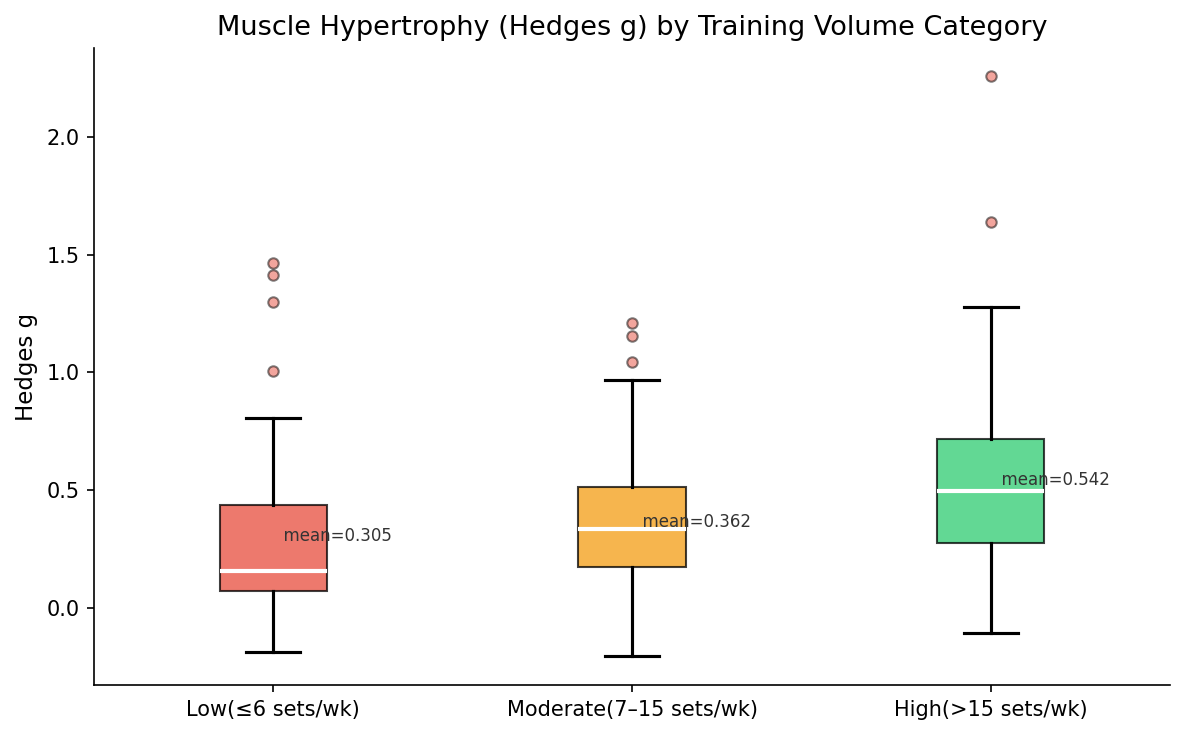

Saved: fig2_boxplot_volume_category.png


In [8]:
fig, ax = plt.subplots(figsize=(8,5))

groups = [df[df["volume_category"]==g]["hedges_g"].dropna() for g in ["Low","Moderate","High"]]
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2),
                whiskerprops=dict(lw=1.5),
                capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markersize=5, alpha=0.5))

for patch, color in zip(bp["boxes"], ["#E74C3C","#F39C12","#2ECC71"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Annotate means
means = [g.mean() for g in groups]
for i, m in enumerate(means):
    ax.text(i+1, m, f"  mean={m:.3f}", va="center", fontsize=8, color="#333333")

ax.set_xticklabels(["Low(≤6 sets/wk)","Moderate(7–15 sets/wk)","High(>15 sets/wk)"])
ax.set_ylabel("Hedges g")
ax.set_title("Muscle Hypertrophy (Hedges g) by Training Volume Category")
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig2_boxplot_volume_category.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig2_boxplot_volume_category.png")

## 5. Figure 3 — Boxplot Hedges g theo Train Status

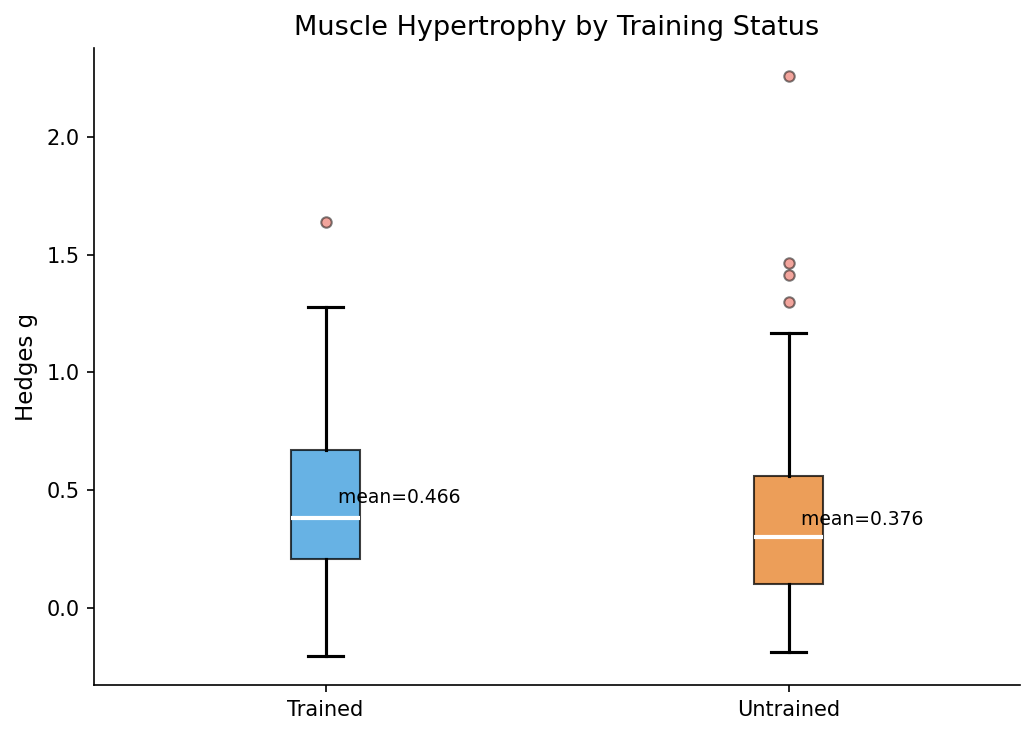

Saved: fig3_boxplot_train_status.png


In [9]:
fig, ax = plt.subplots(figsize=(7,5))

statuses = ["trained","untrained"]
status_labels = ["Trained","Untrained"]
groups = [df[df["train.status"]==s]["hedges_g"].dropna() for s in statuses]

bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2),
                whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markersize=5, alpha=0.5))

for patch, color in zip(bp["boxes"], ["#3498DB","#E67E22"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

means = [g.mean() for g in groups]
for i, m in enumerate(means):
    ax.text(i+1, m, f"  mean={m:.3f}", va="center", fontsize=9)

ax.set_xticklabels(status_labels)
ax.set_ylabel("Hedges g")
ax.set_title("Muscle Hypertrophy by Training Status")
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig3_boxplot_train_status.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig3_boxplot_train_status.png")

## 6. Figure 4 — Boxplot Hedges g theo Upper/Lower Body

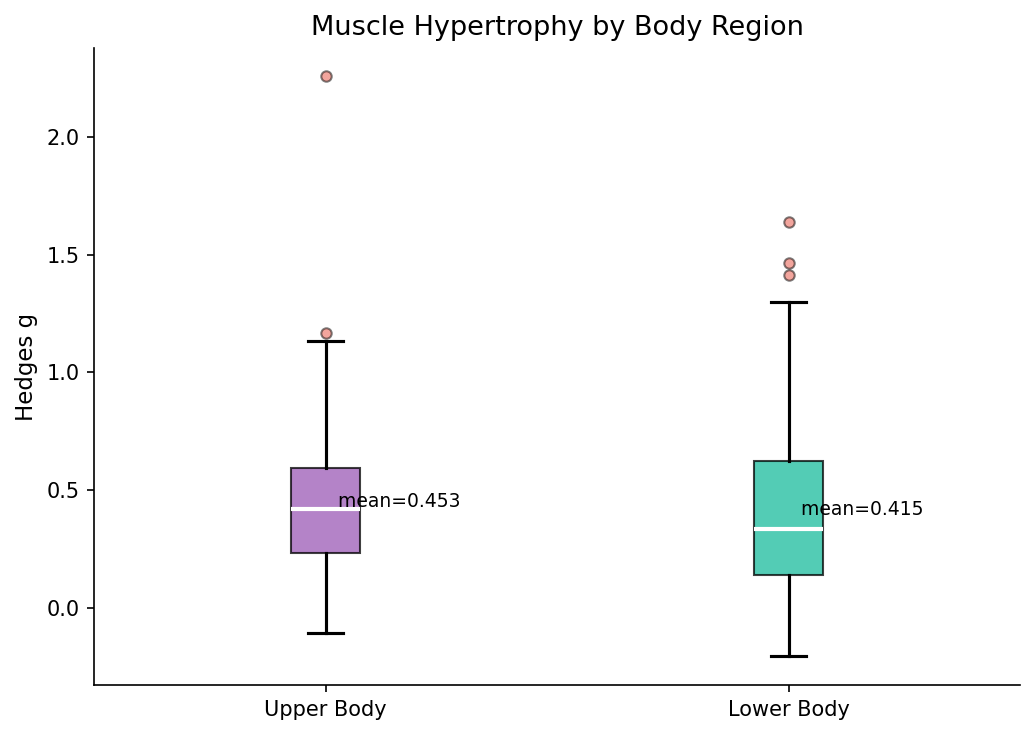

Saved: fig4_boxplot_upper_lower.png


In [10]:
fig, ax = plt.subplots(figsize=(7,5))

ul_groups = [
    df[df["upper.lower"]=="upper"]["hedges_g"].dropna(),
    df[df["upper.lower"]=="lower"]["hedges_g"].dropna()
]

bp = ax.boxplot(ul_groups, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2),
                whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markersize=5, alpha=0.5))

for patch, color in zip(bp["boxes"], ["#9B59B6","#1ABC9C"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

means = [g.mean() for g in ul_groups]
for i, m in enumerate(means):
    ax.text(i+1, m, f"  mean={m:.3f}", va="center", fontsize=9)

ax.set_xticklabels(["Upper Body","Lower Body"])
ax.set_ylabel("Hedges g")
ax.set_title("Muscle Hypertrophy by Body Region")
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig4_boxplot_upper_lower.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig4_boxplot_upper_lower.png")

## 7. Figure 5 — Scatter plot: sets/week vs Hedges g

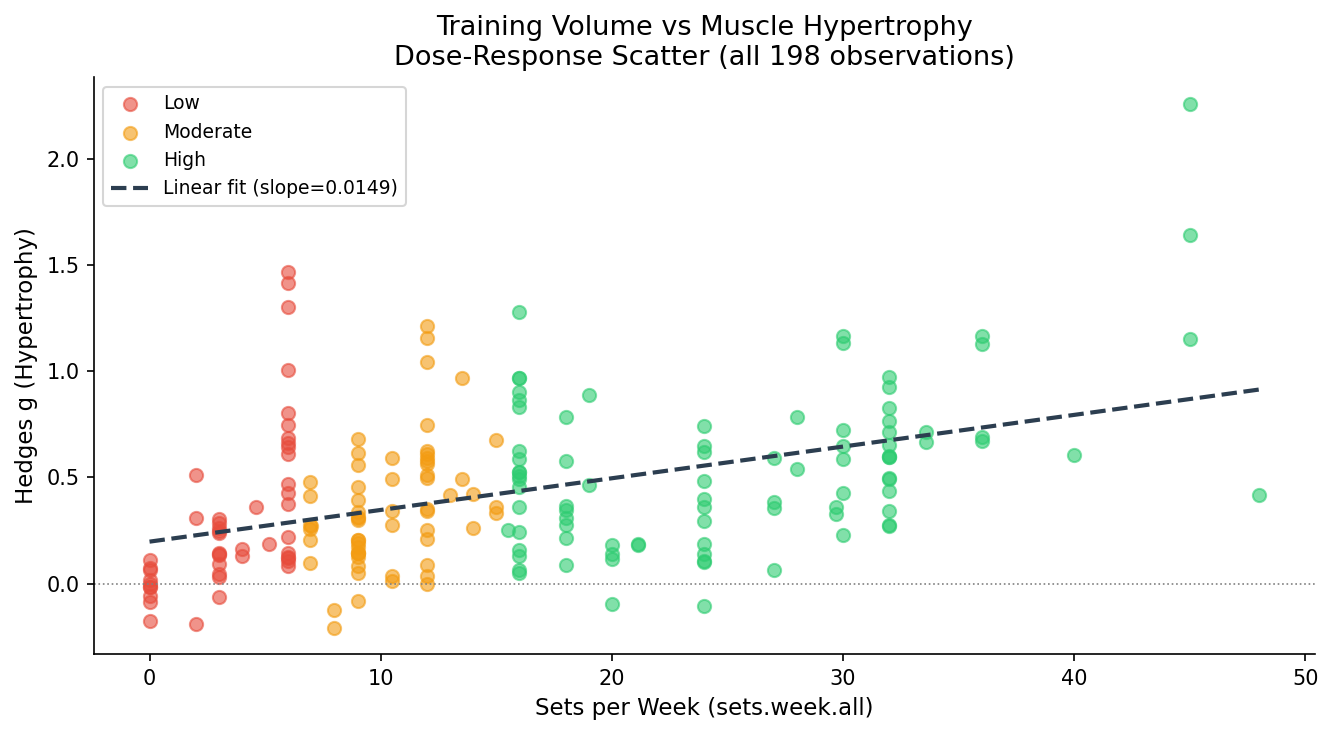

Pearson r = 0.4394, p-value = 0.0000
Saved: fig5_scatter_volume_hypertrophy.png


In [11]:
from numpy.polynomial import polynomial as P

fig, ax = plt.subplots(figsize=(9,5))

color_map = {"Low":"#E74C3C","Moderate":"#F39C12","High":"#2ECC71"}
for cat in ["Low","Moderate","High"]:
    sub = df[df["volume_category"]==cat]
    ax.scatter(sub["sets.week.all"], sub["hedges_g"],
               color=color_map[cat], alpha=0.6, s=40, label=cat)

# Regression line
x = df["sets.week.all"].values
y = df["hedges_g"].values
mask = ~np.isnan(x) & ~np.isnan(y)
z = np.polyfit(x[mask], y[mask], 1)
p_fn = np.poly1d(z)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, p_fn(x_line), color="#2C3E50", lw=2, ls="--", label=f"Linear fit (slope={z[0]:.4f})")

ax.set_xlabel("Sets per Week (sets.week.all)")
ax.set_ylabel("Hedges g (Hypertrophy)")
ax.set_title("Training Volume vs Muscle Hypertrophy\nDose-Response Scatter (all 198 observations)")
ax.legend(fontsize=9)
ax.axhline(0, color="gray", lw=0.8, ls=":")
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig5_scatter_volume_hypertrophy.png", dpi=300, bbox_inches="tight")
plt.show()

# Pearson r
from scipy import stats
r, p_val = stats.pearsonr(x[mask], y[mask])
print(f"Pearson r = {r:.4f}, p-value = {p_val:.4f}")
print("Saved: fig5_scatter_volume_hypertrophy.png")

## 8. Summary output

In [12]:
print("="*55)
print("DESCRIPTIVE STATS SUMMARY")
print("="*55)
print(f"  Total observations:  {len(df)}")
print(f"  hedges_g mean:       {df['hedges_g'].mean():.4f}")
print(f"  hedges_g median:     {df['hedges_g'].median():.4f}")
print(f"  hedges_g SD:         {df['hedges_g'].std():.4f}")
print(f"  hedges_g range:      [{df['hedges_g'].min():.4f}, {df['hedges_g'].max():.4f}]")
print(f"  sets/week mean:      {df['sets.week.all'].mean():.2f}")
print(f"  sets/week range:     [{df['sets.week.all'].min()}, {df['sets.week.all'].max()}]")
print()
print("  Volume groups:")
for cat in ["Low","Moderate","High"]:
    sub = df[df["volume_category"]==cat]
    print(f"    {cat:8s}: n={len(sub):3d}, g_mean={sub['hedges_g'].mean():.4f}")
print()
print("FILES SAVED:")
print("  descriptive_stats.csv")
print("  fig1_hedges_g_distribution.png")
print("  fig2_boxplot_volume_category.png")
print("  fig3_boxplot_train_status.png")
print("  fig4_boxplot_upper_lower.png")
print("  fig5_scatter_volume_hypertrophy.png")

DESCRIPTIVE STATS SUMMARY
  Total observations:  198
  hedges_g mean:       0.4291
  hedges_g median:     0.3603
  hedges_g SD:         0.3698
  hedges_g range:      [-0.2080, 2.2588]
  sets/week mean:      15.50
  sets/week range:     [0.0, 48.0]

  Volume groups:
    Low     : n= 48, g_mean=0.3051
    Moderate: n= 61, g_mean=0.3624
    High    : n= 89, g_mean=0.5416

FILES SAVED:
  descriptive_stats.csv
  fig1_hedges_g_distribution.png
  fig2_boxplot_volume_category.png
  fig3_boxplot_train_status.png
  fig4_boxplot_upper_lower.png
  fig5_scatter_volume_hypertrophy.png
